### 1. Import Library & Load Data (Real Case: Titanic)
Memuat library wajib dan membaca dataset `titanic.csv` agar visualisasi data didasarkan pada *real case*.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load real data dari folder data
df = pd.read_csv('../data/titanic.csv')
display(df.head(3))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


### 2. Plotting Bar Chart (Distribusi Kategori)
Melihat distribusi jumlah penumpang yang *Survived* (Selamat) vs *Died* (Meninggal). Bar chart sangat cocok untuk menghitung kemunculan label klasifikasi.

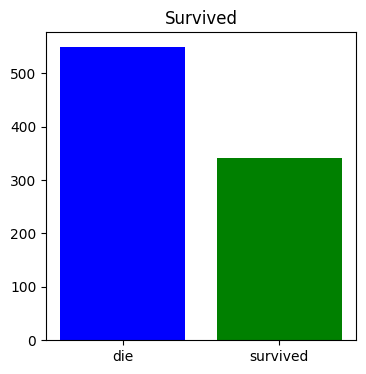

In [ ]:
labels, counts = np.unique(df['Survived'].values, return_counts=True)
label_map = np.array(['die', 'survived'])
label = label_map[labels]
label
plt.figure(figsize=(4,4))
plt.title('Survived')
plt.bar(labels, counts, color=['b', 'g'])
plt.xticks(labels, label)
plt.show()

### 3. Plotting Line Chart (Melihat Tren Berdasarkan Urutan/Kelas)
Misalnya kita ingin melihat bagaimana rata-rata harga tiket (`Fare`) berubah dibandingkan dengan Kelas Penumpang (`Pclass`).

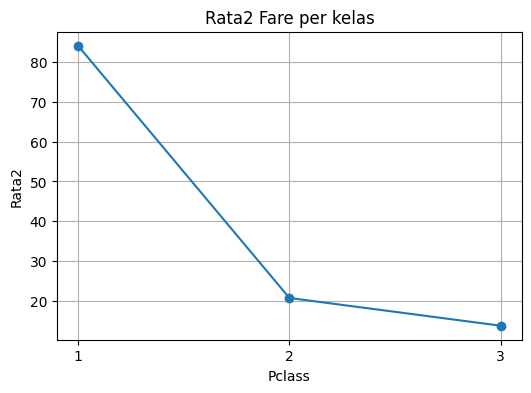

In [ ]:
fare_by_class = df.groupby('Pclass')['Fare'].mean()


plt.figure(figsize=(6, 4))
plt.plot(fare_by_class.index, fare_by_class.values, marker='o', linestyle='-')
plt.title('Rata2 Fare per kelas')
plt.xlabel('Pclass')
plt.ylabel('Rata2')
plt.xticks(fare_by_class.index)
plt.grid(True)
plt.show()

### 4. Membuat Subplot & Axes (Beberapa Grafik Sampingan)
Mendefinisikan kanvas untuk >1 grafik sekaligus. Misalnya melihat Bar Chart untuk Embarked dan Pclass secara bersebelahan.

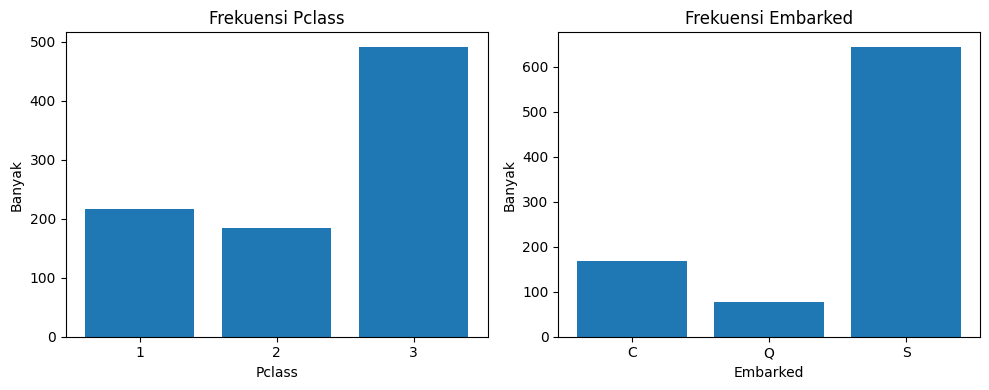

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
pclasscounts = df['Pclass'].value_counts().sort_index()
ax[0].bar(pclasscounts.index.astype(str), pclasscounts.values)
ax[0].set_title('Frekuensi Pclass')
ax[0].set_xlabel('Pclass')
ax[0].set_ylabel('Banyak')

pclasscounts = df['Embarked'].value_counts().sort_index()
ax[1].bar(pclasscounts.index.astype(str), pclasscounts.values)
ax[1].set_title('Frekuensi Embarked')
ax[1].set_xlabel('Embarked')
ax[1].set_ylabel('Banyak')
plt.tight_layout()
plt.show()
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# # Grafik 1 di kiri
# pclass_counts = df['Pclass'].value_counts().sort_index()
# ax[0].bar(pclass_counts.index.astype(str), pclass_counts.values, color='gold')
# ax[0].set_title('Penumpang per Kelas')
# ax[0].set_xlabel('Pclass')

# # Grafik 2 di kanan
# embarked_counts = df['Embarked'].value_counts()
# ax[1].bar(embarked_counts.index, embarked_counts.values, color='cyan')
# ax[1].set_title('Penumpang per Titik Keberangkatan')
# ax[1].set_xlabel('Embarked')

# plt.tight_layout()
# plt.show()

### 5. Heatmap Pearson Correlation dengan Seaborn
Sebelum melatih data tabuler (Machine Learning), sangat penting mengecek korelasi antar kolom numerik. `sns.heatmap` dikawinkan dengan `.corr()` milik pandas.

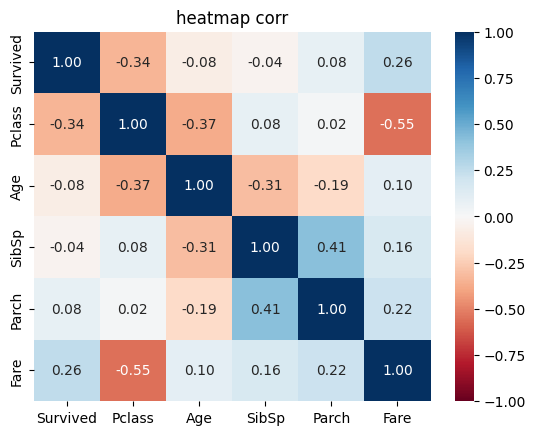

In [ ]:
numeric_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('heatmap corr')
plt.show()

### 6. Histogram (Distribusi Frekuensi Numerik)
Melihat persebaran umur penumpang kapal menggunakan *Histogram*. Semakin tinggi batangnya, semakin mayoritas rentang usia tersebut.

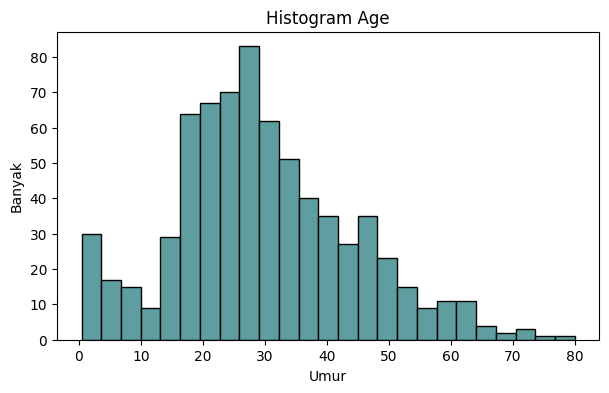

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df['Age'].dropna(), bins=25, color='cadetblue', edgecolor='black')
plt.title('Histogram Age')
plt.xlabel('Umur')
plt.ylabel('Banyak')
plt.show()

### 7. Box Plot (Mendeteksi Outlier Data)
Melihat pencilan (*outliers*) dari harga tiket kapal (`Fare`) berdasarkan Kelas (`Pclass`). Karena data Fare untuk kelas 1 sangat ekstrim, box plot akan menampilkannya sebagai titik-titik melayang.

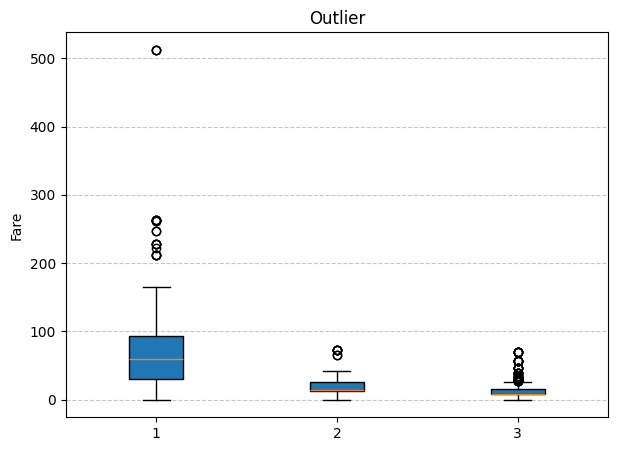

In [95]:
fare_p1 = df[df['Pclass']==1]['Fare'].dropna()
fare_p2 = df[df['Pclass']==2]['Fare'].dropna()
fare_p3 = df[df['Pclass']==3]['Fare'].dropna()

plt.figure(figsize=(7,5))
plt.boxplot([fare_p1, fare_p2, fare_p3], label=['p1', 'p2', 'p3'], patch_artist='True')
plt.title('Outlier')
plt.ylabel('Fare')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 8. Scatter Plot (Sebaran Titik Kolerasi)
Mari kita hubungkan secara spesifik `Age` di sumbu X dan `Fare` di sumbu Y untuk melihat apakah penumpang tua cenderung membayar tiket lebih mahal.

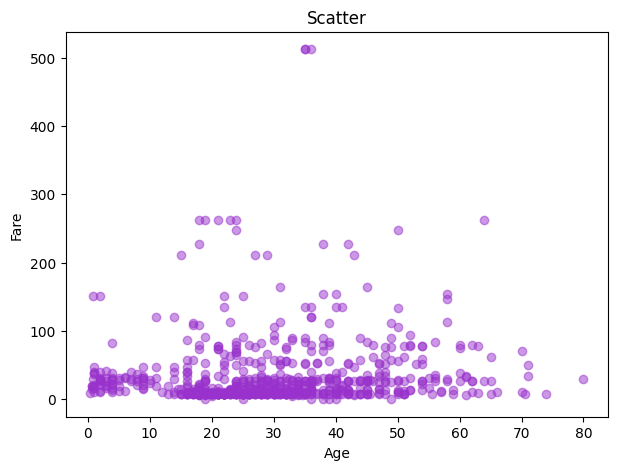

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, color='darkorchid')
plt.title('Scatter')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

### 9. Pie Chart (Komposisi Persentase)
Melihat persentase Gender (`Sex`) di kapal Titanic.

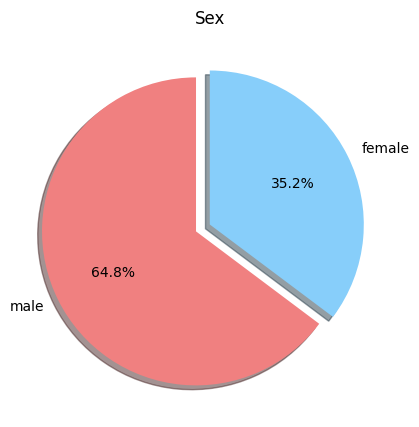

In [109]:
gernder_counts = df['Sex'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(gernder_counts.values, labels=gernder_counts.index, colors=['lightcoral', 'lightskyblue'], shadow=True, startangle=90, explode=(0.1,0), autopct='%1.1f%%')
plt.title('Sex')
plt.show()

### 10. Menyimpan Plot Gambar (`savefig`)
Contoh untuk mengekspor visualisasi dari data riil.

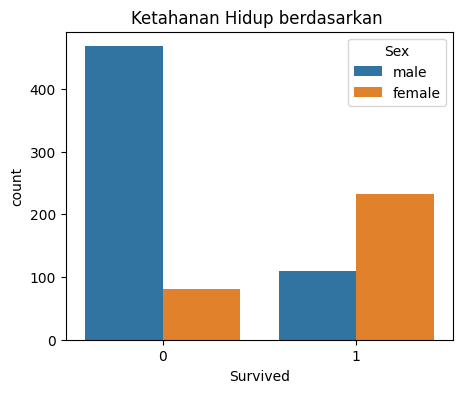

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(df, hue='Sex', x='Survived')
plt.title('Ketahanan Hidup berdasarkan ')
plt.savefig('tes.png', dpi=300, bbox_inches='tight')
plt.show()